# 말벌 포함 여부 이진분류 학습 — 혼합음 대체 수정본

- non_wasp=0: 말벌이 없는 꿀벌/환경음. wasp=1: 말벌 단독 또는 말벌 포함 혼합음.
- 말벌 Train의 일부를 혼합음으로 **대체**합니다. 원본 WAV와 클래스별 학습 개수는 유지합니다.
- 혼합은 Train에서만 수행하며 Validation/Test와 시연 음원에는 적용하지 않습니다.
- 데이터 배치: `audio/<클래스>/<원본ID>/*.wav` (라벨을 확인한 2초 이하 구간).
- 학습 전에 `mixing_summary.json`, `mixing_manifest.csv` 및 필수 점검 셀을 확인하세요.
- 원본ID 분할은 파일명만으로 독립성을 보장하지 않습니다. 실제 녹음 출처를 확인해야 합니다.
- `src/`의 공통 전처리·추론 코드는 별도 파일이며 이 노트북에 포함되어 있지 않습니다.
- 새 모델은 `models/`에 저장됩니다.
- 커널 재시작 후 위에서부터 실행. 임계값 변경 시 평가도 다시 실행하세요.


In [1]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
! pip install numpy pandas matplotlib seaborn librosa pillow scikit-learn tensorflow image lightgbm xgboost

In [3]:
%pip list

Package            Version
------------------ ------------
absl-py            2.5.0
annotated-doc      0.0.5
annotated-types    0.8.0
anyio              4.15.1
asgiref            3.12.1
asttokens          3.0.2
astunparse         1.6.3
audioread          3.1.0
certifi            2026.7.22
cffi               2.1.1
charset-normalizer 3.5.1
click              8.5.0
colorama           0.4.6
comm               0.2.3
contourpy          1.3.2
cycler             0.12.1
debugpy            1.8.21
decorator          5.3.1
Django             5.2.17
exceptiongroup     1.3.1
executing          2.2.1
fastapi            0.141.1
flatbuffers        25.12.19
fonttools          4.63.0
gast               0.7.0
google-pasta       0.2.0
grpcio             1.83.1
h11                0.16.0
h5py               3.14.0
httpcore           1.0.9
httptools          0.8.0
httpx              0.28.1
idna               3.19
image              1.5.33
ipykernel          7.3.0
ipython            8.39.0
jedi               0.

# 1. 환경 설정

In [4]:
# 저장소 루트 또는 ai_model에서 실행 가능
import sys
from pathlib import Path
notebook_root = Path.cwd() if (Path.cwd() / 'src' / 'config.py').is_file() else Path.cwd() / 'ai_model'
if not (notebook_root / 'src' / 'config.py').is_file():
    raise RuntimeError('Buzz 또는 ai_model 폴더에서 노트북을 실행하세요.')
sys.path.insert(0, str(notebook_root))
import os                           # 폴더 / 파일 경로 처리
import glob                         # 특정 패턴의 파일 검색 (예: .wav .mp3 등)
import random                       # 랜덤 샘플 선택

import numpy as np                  # 오디오 파형, 행렬 계산
import pandas as pd                 # 데이터프레임
import matplotlib.pyplot as plt     # 그래프 (시각화)
import seaborn as sns               # confusion matrix 등 시각화
%matplotlib inline

import librosa                      # wav 로딩, waveform, FFT/STFT, Mel Spectrogram, MFCC 등 대부분 처리
import librosa.display

import joblib

from sklearn.metrics import (       # 모델 성능 평가
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 머신러닝 3종
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 데이터 분할
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# 딥러닝 (CNN, CRNN, MobileNetV2)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

In [5]:
# 학습과 추론이 같은 클래스 순서, 전처리, 저장 경로를 사용한다.
from src.config import (
    BASE_DIR, AUDIO_DIR, MODEL_DIR, CLASSES, WASP_INDEX, WASP_THRESHOLD,
    SR, DURATION, SAMPLES_PER_TRACK, TARGET_DB,
    IMG_HEIGHT, IMG_WIDTH, N_FFT, HOP_LENGTH, N_MELS,
)
from src.binary_classification import predict_classes, ordered_ml_probabilities
from src.dataset import collect_audio_files, split_by_source

BATCH_SIZE = 16
EPOCHS = 50
print('Classes:', dict(enumerate(CLASSES)))
print('Audio:', AUDIO_DIR)
print('Binary models:', MODEL_DIR)
print('Wasp threshold:', WASP_THRESHOLD)

Classes: {0: 'non_wasp', 1: 'wasp'}
Audio: E:\AI_First_Team_Project\Buzz\ai_model\audio
Binary models: E:\AI_First_Team_Project\Buzz\ai_model\models
Wasp threshold: 0.5


# 2. 데이터셋 확인 및 기본 유틸리티

In [6]:
def ensure_directory_exists(dir_path):
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# audio/non_wasp/<원본ID>/*.wav, audio/wasp/<원본ID>/*.wav
# 말벌 단독/혼합 모두 wasp. 2초 이하로 잘라 구간별 라벨을 확인한다.
records = collect_audio_files(AUDIO_DIR)

,Class,Count,Ratio
0,non_wasp,1000,0.5
1,wasp,1000,0.5


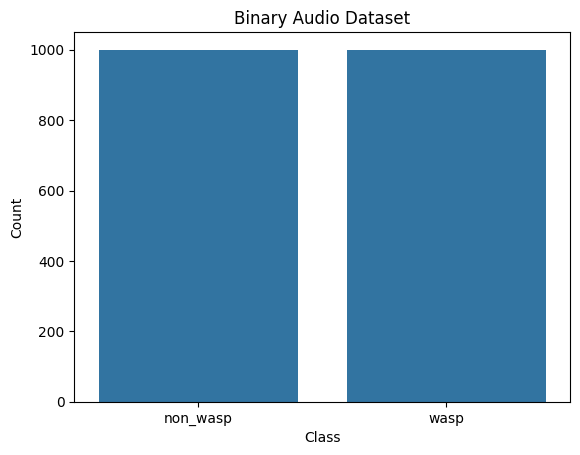

In [7]:
file_counts = {cls: sum(row['label'] == i for row in records) for i, cls in enumerate(CLASSES)}
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=['Class', 'Count'])
file_counts_df['Ratio'] = file_counts_df['Count'] / file_counts_df['Count'].sum()
display(file_counts_df)
sns.barplot(data=file_counts_df, x='Class', y='Count')
plt.title('Binary Audio Dataset')
plt.show()

# 3. 오디오 전처리 및 EDA

In [8]:
from src.audio_preprocessing import load_audio_file, normalize_rms
# 랜덤 crop 없이 학습과 추론에서 동일한 2초 전처리를 사용한다.


In [9]:
sample_files = {
    cls: next(row['path'] for row in records if row['label'] == i)
    for i, cls in enumerate(CLASSES)
}
for cls, audio_path in sample_files.items():
    y_sample, sr_sample = load_audio_file(audio_path)
    print(cls, audio_path, sr_sample, len(y_sample))

non_wasp E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\15-12-22_with_sound_02\bee_candidate_001_00082.0s.wav 24000 48000
wasp E:\AI_First_Team_Project\Buzz\ai_model\audio\wasp\13-10-22 shotgun 2\wasp_paper_01_003s.wav 24000 48000


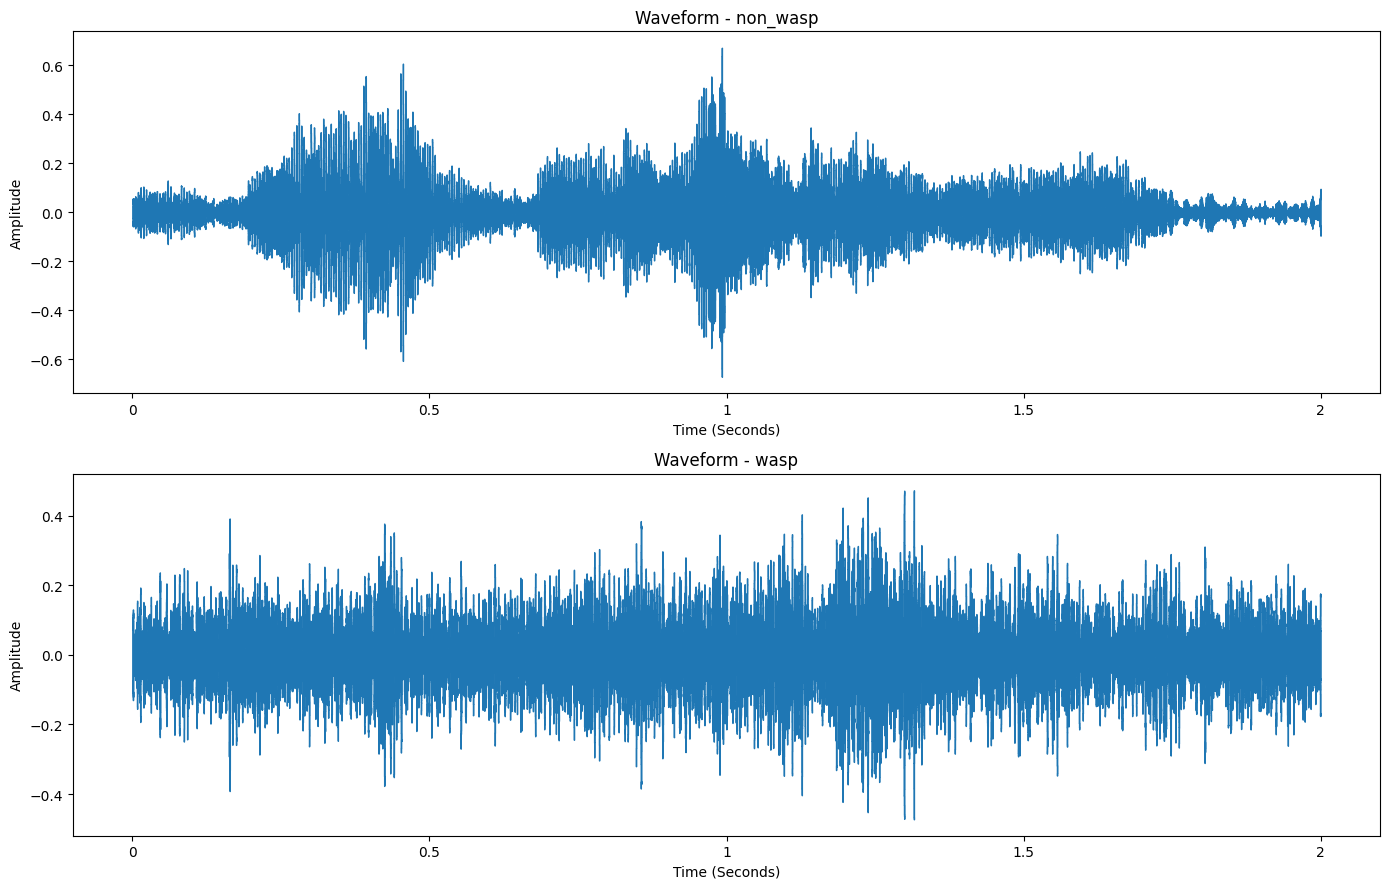

In [10]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    plt.subplot(len(CLASSES), 1, i)

    librosa.display.waveshow(y_sample, sr = sr_sample)

    plt.title(f'Waveform - {cls}')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

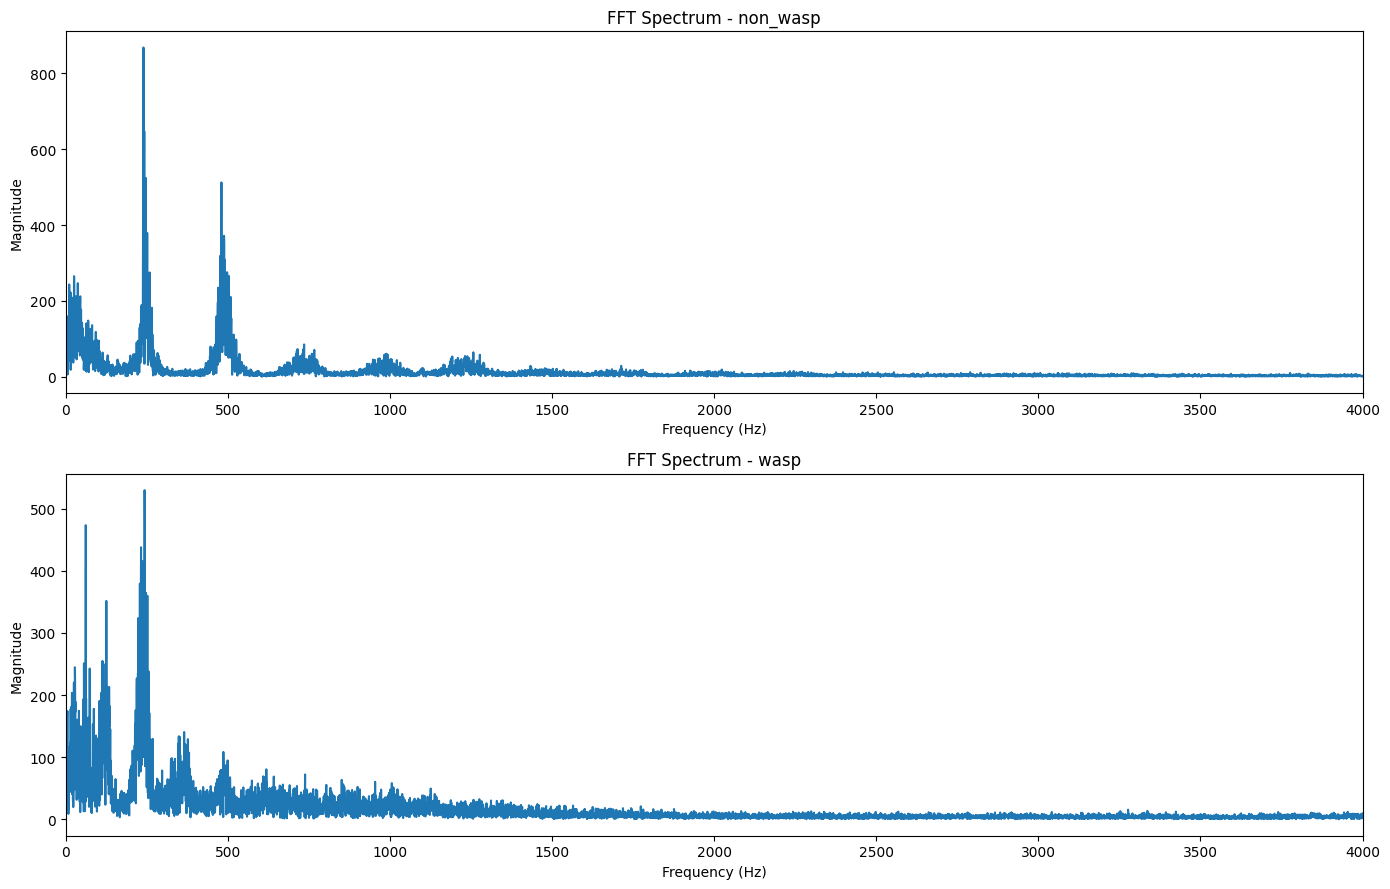

In [11]:
plt.figure(figsize = (14, 9))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # 실수 Audio 신호용 FFT
    fft_sample = np.fft.rfft(y_sample)

    # Magnitude Spectrum
    magnitude_sample = np.abs(fft_sample)

    # Frequency Axis
    freqs_sample = np.fft.rfftfreq(len(y_sample), d = 1 / sr_sample)

    plt.subplot(len(CLASSES), 1, i)

    plt.plot(freqs_sample, magnitude_sample)

    plt.title(f'FFT Spectrum - {cls}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')

    plt.xlim(0, sr_sample / 6)

plt.tight_layout()
plt.show()

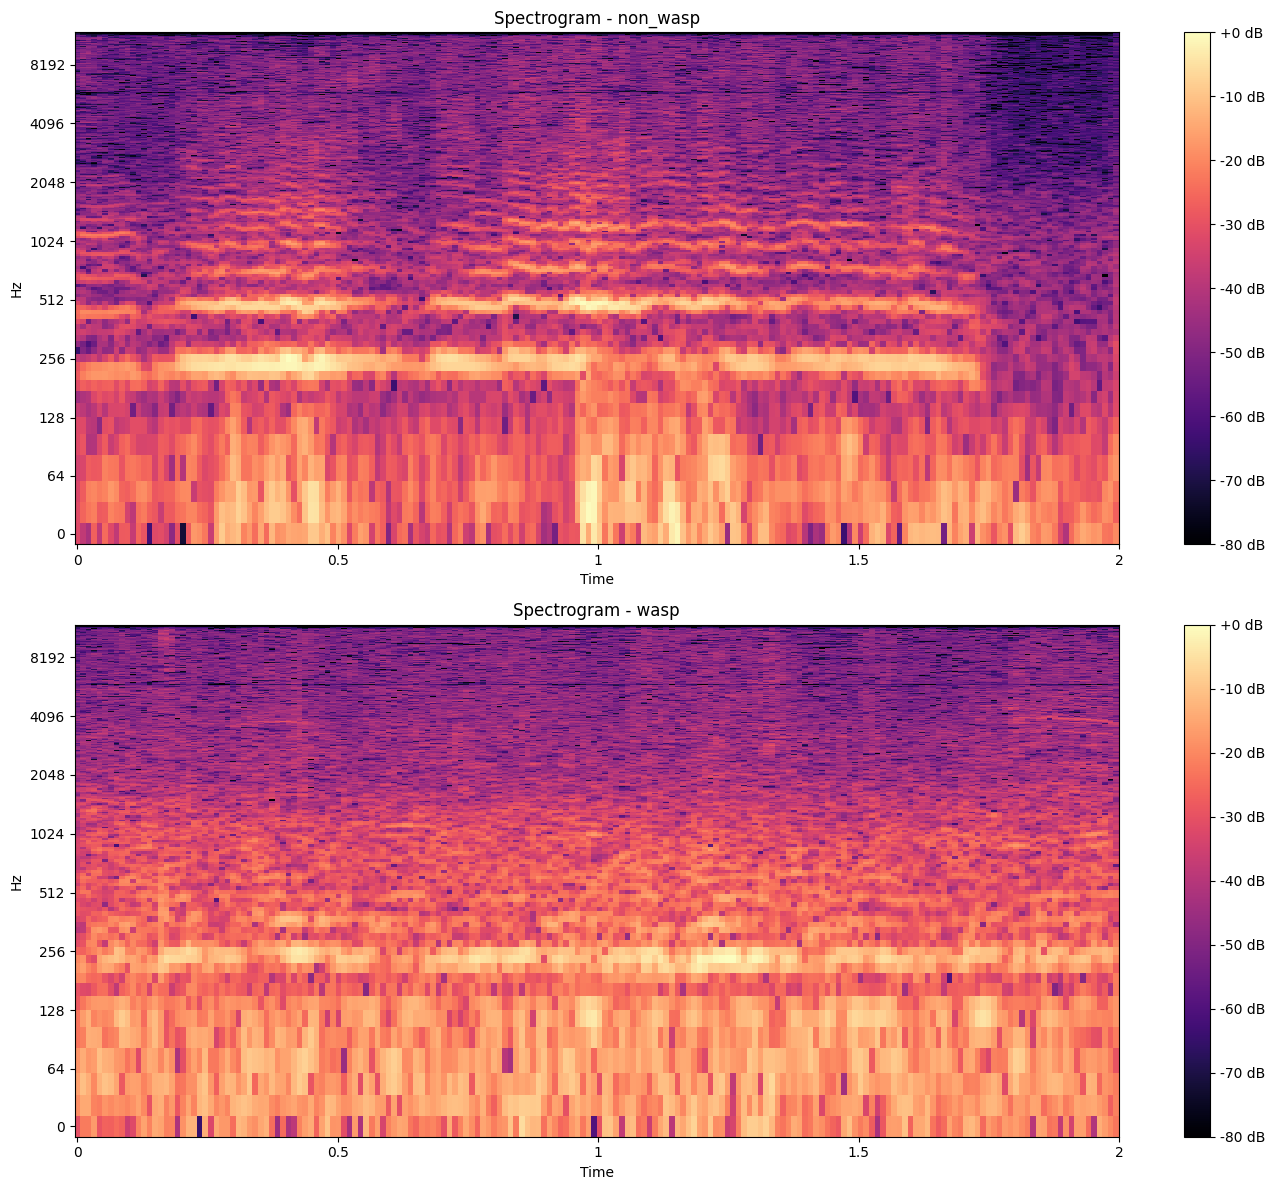

In [12]:
plt.figure(figsize = (14, 12))

for i, (cls, sample_file) in enumerate(sample_files.items(), start = 1):
    y_sample, sr_sample = load_audio_file(sample_file)

    # STFT
    stft_sample = librosa.stft(y_sample, n_fft = N_FFT, hop_length = HOP_LENGTH)

    # Magnitude Spectrogram
    spectrogram_sample = np.abs(stft_sample)

    # dB 변환
    spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref = np.max)

    plt.subplot(len(CLASSES), 1, i)

    img = librosa.display.specshow(
        spectrogram_db_sample,
        sr = sr_sample,
        hop_length = HOP_LENGTH,
        x_axis = 'time',
        y_axis = 'log',
        cmap = 'magma'
    )

    plt.colorbar(img, format = '%+2.0f dB')
    plt.title(f'Spectrogram - {cls}')

plt.tight_layout()
plt.show()

# 4. Deep Learning

## 4-1. Mel-Spectrogram 데이터셋 구성

In [13]:
from src.audio_preprocessing import create_mel_spectrogram_from_audio
from src.feature_extraction import extract_audio_features_from_audio

In [14]:
# 같은 파형에서 DL/ML 특징을 함께 생성하여 구간·라벨·순서를 일치시킨다.
mel_data, ml_features = [], []
for row in records:
    y_audio, sr_audio = load_audio_file(row['path'])
    mel_data.append(create_mel_spectrogram_from_audio(y_audio, sr_audio))
    ml_features.append(extract_audio_features_from_audio(y_audio, sr_audio))

X_mel = np.asarray(mel_data, dtype=np.float32)
y_mel = np.asarray([row['label'] for row in records], dtype=np.int32)
mel_file_paths = np.asarray([row['path'] for row in records])
source_ids = np.asarray([row['source_id'] for row in records])
X_ml = np.asarray(ml_features, dtype=np.float32)
y_ml = y_mel.copy()
ml_file_paths = mel_file_paths.copy()
print('Mel:', X_mel.shape, 'ML:', X_ml.shape, 'Labels:', y_mel.shape)

Mel: (2000, 128, 188) ML: (2000, 74) Labels: (2000,)


In [15]:
# 원본 영상/녹음 단위 분리. 같은 원본의 잘린 구간은 하나의 split에만 포함된다.
train_indices, val_indices, test_indices = split_by_source(y_mel, source_ids, seed=SEED)
# wind는 증강 재료로만 사용하므로 Train 전용으로 고정하고 평가에서는 제외한다.
wind_indices = np.flatnonzero(source_ids == 'wind')
if len(wind_indices) == 0:
    raise ValueError('non_wasp/wind에 증강용 WAV가 필요합니다.')
train_indices = np.unique(np.concatenate([train_indices, wind_indices])).astype(int)
val_indices = np.setdiff1d(val_indices, wind_indices)
test_indices = np.setdiff1d(test_indices, wind_indices)
assert set(source_ids[wind_indices]) == {'wind'}
assert not set(wind_indices) & (set(val_indices) | set(test_indices))
X_train_mel, X_val_mel, X_test_mel = [X_mel[i] for i in (train_indices, val_indices, test_indices)]
y_train_mel, y_val_mel, y_test_mel = [y_mel[i] for i in (train_indices, val_indices, test_indices)]
paths_train_mel, paths_val_mel, paths_test_mel = [mel_file_paths[i] for i in (train_indices, val_indices, test_indices)]

# 학습 세트만으로 클래스 불균형 보정. 말벌=1을 양성으로 취급한다.
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)))
for name, indices in zip(('Train', 'Validation', 'Test'), (train_indices, val_indices, test_indices)):
    print(name, 'segments:', len(indices), 'sources:', len(set(source_ids[indices])),
          {cls: int(np.sum(y_mel[indices] == i)) for i, cls in enumerate(CLASSES)})

# 재현/누수 점검용 분할 목록 저장(음원은 이동하지 않는다).
ensure_directory_exists(MODEL_DIR)
split_rows = []
for name, indices in zip(('train', 'validation', 'test'), (train_indices, val_indices, test_indices)):
    for i in indices:
        split_rows.append({**records[i], 'split': name})
pd.DataFrame(split_rows).to_csv(MODEL_DIR / 'dataset_split.csv', index=False)

Train segments: 1638 sources: 17 {'non_wasp': 775, 'wasp': 863}
Validation segments: 159 sources: 3 {'non_wasp': 60, 'wasp': 99}
Test segments: 203 sources: 4 {'non_wasp': 165, 'wasp': 38}


### Train 전용 혼합음 학습
말벌 Train 구간의 약 절반을 메모리에서 혼합음으로 대체합니다. 전체 개수와 라벨은 유지하며 원본 WAV·Validation·Test는 변경하지 않습니다.


In [16]:
# ===== Train 전용 혼합음 대체 =====
# 원본 폴더/WAV는 변경하지 않습니다. 합성 파형은 메모리에서만 만듭니다.
# 반드시 원본별 Train/Validation/Test 분리 다음, 모델 입력 생성 전에 실행합니다.
ENABLE_MIXING = False      # 수동 데이터 교체 실험: wasp/non_wasp 온라인 혼합 모두 비활성화
MIX_REPLACE_RATIO = 0.5    # 말벌 Train의 절반을 혼합음으로 대체(파일 수 유지)
NON_WASP_MIX_REPLACE_RATIO = 0.5  # Train의 환경음 없는 꿀벌 샘플 절반을 wind와 혼합
NON_WASP_BACKGROUND_SOURCES = ('wind',)
MIX_SNR_DB = (10.0, 5.0, 0.0, -5.0)
# SNR: +10은 말벌이 배경보다 큼, 0은 같음, -5는 배경보다 작음.
# 위 값은 실험 시작값이며 실제 환경에서 검증된 최적값은 아닙니다.


def mix_wasp_background(wasp_audio, background_audio, snr_db):
    """두 파형의 RMS 비율을 맞춰 합성. 무음은 합성 대상으로 사용하지 않음."""
    wasp_audio = np.asarray(wasp_audio, dtype=np.float32)
    background_audio = np.asarray(background_audio, dtype=np.float32)
    if wasp_audio.ndim != 1 or wasp_audio.shape != background_audio.shape:
        raise ValueError('같은 길이의 모노 파형이 필요합니다.')
    if not np.isfinite(snr_db) or not np.all(np.isfinite(wasp_audio)) or not np.all(np.isfinite(background_audio)):
        raise ValueError('합성 입력은 유한한 값이어야 합니다.')
    wasp_rms = np.sqrt(np.mean(wasp_audio.astype(np.float64) ** 2))
    background_rms = np.sqrt(np.mean(background_audio.astype(np.float64) ** 2))
    if min(wasp_rms, background_rms) < 1e-8:
        return None
    background_scale = wasp_rms / (background_rms * 10 ** (snr_db / 20))
    mixed = wasp_audio + background_scale * background_audio
    # 개별 샘플을 잘라내지 않고 전체 음량을 줄여 파형과 상대 음량을 보존합니다.
    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        mixed = mixed / peak
    return normalize_rms(mixed).astype(np.float32)


# 셀을 다시 실행해도 혼합음이 중복 누적되지 않도록 원본 Train에서 시작합니다.
X_train_mel = X_mel[train_indices].copy()
y_train_mel = y_mel[train_indices].copy()
replacement_positions, replacement_ml, mixing_rows = [], [], []
skipped = non_wasp_skipped = wasp_mixed_count = 0
excluded_environment_sources = []
if ENABLE_MIXING:
    if not np.isfinite(MIX_REPLACE_RATIO) or not 0 <= MIX_REPLACE_RATIO <= 1:
        raise ValueError('MIX_REPLACE_RATIO는 0~1이어야 합니다.')
    if not MIX_SNR_DB or not np.all(np.isfinite(MIX_SNR_DB)):
        raise ValueError('유한한 SNR 값을 지정하세요.')
    rng = np.random.default_rng(SEED)
    wasp_indices = [int(i) for i in train_indices if y_mel[i] == WASP_INDEX]
    # Validation/Test에 있는 바람·꿀벌 소리는 배경으로도 가져오지 않습니다.
    background_groups = {}
    for i in train_indices:
        if y_mel[i] != WASP_INDEX:
            background_groups.setdefault(str(source_ids[i]), []).append(int(i))
    if not wasp_indices or not background_groups:
        raise ValueError('Train에 말벌음과 일반음이 모두 있어야 합니다.')
    background_sources = sorted(background_groups)
    print('합성에 사용하는 Train 배경 원본:', background_sources)
    background_cache = {}
    skipped = 0
    max_background_attempts = 12
    source_audit = []
    # 중복 없이 절반을 선택. 같은 SEED와 입력이면 동일한 구간을 선택합니다.
    replace_count = int(len(wasp_indices) * MIX_REPLACE_RATIO)
    selected_indices = rng.choice(wasp_indices, size=replace_count, replace=False)
    train_position = {int(index): position for position, index in enumerate(train_indices)}
    for wasp_index in selected_indices:
        wasp_path = str(mel_file_paths[wasp_index])
        wasp_audio, sr_audio = load_audio_file(wasp_path)
        # 무음 배경은 재시도하고, 유효한 배경을 찾지 못하면 원본을 유지합니다.
        # 원본을 먼저 선택하여 파일 수가 많은 녹음에 치우치지 않도록 합니다.
        mixed = None
        for _ in range(max_background_attempts):
            background_source = str(rng.choice(background_sources))
            background_index = int(rng.choice(background_groups[background_source]))
            background_path = str(mel_file_paths[background_index])
            if background_index not in background_cache:
                background_cache[background_index] = load_audio_file(background_path)[0]
            snr_db = float(rng.choice(MIX_SNR_DB))
            mixed = mix_wasp_background(wasp_audio, background_cache[background_index], snr_db)
            if mixed is not None:
                break
        if mixed is None:
            skipped += 1
            continue  # 무음이면 해당 구간은 원래 특징을 유지합니다.
        mel_features = create_mel_spectrogram_from_audio(mixed, sr_audio)
        ml_features = extract_audio_features_from_audio(mixed, sr_audio)
        position = train_position[int(wasp_index)]
        # 배열 뒤에 추가하지 않고 선택한 원본 구간의 특징만 교체합니다.
        X_train_mel[position] = mel_features
        replacement_positions.append(position)
        replacement_ml.append(ml_features)
        mixing_rows.append({'train_position': position, 'wasp_path': wasp_path,
                            'background_path': background_path, 'wasp_source_id': str(source_ids[wasp_index]),
                            'background_source_id': background_source, 'snr_db': snr_db,
                            'label': WASP_INDEX, 'split': 'train'})
    wasp_mixed_count = len(mixing_rows)
    # 환경음 없는 꿀벌(bee_part1~10, bee2)에만 적용하며 Train 전용 wind를 사용합니다.
    # 이미 환경음이 섞인 bee3(env)~bee5(env)는 추가 혼합 대상에서 제외합니다.
    environment_groups = {source: background_groups[source] for source in NON_WASP_BACKGROUND_SOURCES
                          if source in background_groups}
    excluded_environment_sources = sorted(set(NON_WASP_BACKGROUND_SOURCES) - set(environment_groups))
    if not environment_groups:
        raise ValueError('Train split에 wind 환경음 원본이 없습니다.')
    clean_bee_sources = {'bee2'} | {f'bee_part{i}' for i in range(1, 11)}
    bee_indices = [int(i) for i in train_indices
                   if y_mel[i] != WASP_INDEX and str(source_ids[i]) in clean_bee_sources]
    bee_replace_count = int(len(bee_indices) * NON_WASP_MIX_REPLACE_RATIO)
    selected_bee_indices = rng.choice(bee_indices, size=bee_replace_count, replace=False)
    non_wasp_skipped = 0
    for bee_index in selected_bee_indices:
        bee_path = str(mel_file_paths[bee_index])
        bee_audio, sr_audio = load_audio_file(bee_path)
        mixed = None
        for _ in range(max_background_attempts):
            background_source = str(rng.choice(sorted(environment_groups)))
            background_index = int(rng.choice(environment_groups[background_source]))
            background_path = str(mel_file_paths[background_index])
            if background_index not in background_cache:
                background_cache[background_index] = load_audio_file(background_path)[0]
            snr_db = float(rng.choice(MIX_SNR_DB))
            mixed = mix_wasp_background(bee_audio, background_cache[background_index], snr_db)
            if mixed is not None:
                break
        if mixed is None:
            non_wasp_skipped += 1
            continue
        position = train_position[bee_index]
        X_train_mel[position] = create_mel_spectrogram_from_audio(mixed, sr_audio)
        replacement_positions.append(position)
        replacement_ml.append(extract_audio_features_from_audio(mixed, sr_audio))
        mixing_rows.append({'train_position': position, 'wasp_path': bee_path,
                            'background_path': background_path, 'wasp_source_id': str(source_ids[bee_index]),
                            'background_source_id': background_source, 'snr_db': snr_db,
                            'label': 0, 'split': 'train', 'augmentation_target': 'non_wasp'})
    for row in mixing_rows[:wasp_mixed_count]:
        row['augmentation_target'] = 'wasp'
    print('말벌 혼합음 대체:', wasp_mixed_count, '/ 원본 유지(무음):', skipped)
    print('꿀벌+환경음 대체:', len(mixing_rows) - wasp_mixed_count, '/ 원본 유지(무음):', non_wasp_skipped)
    print('사용 환경음:', sorted(environment_groups), '/ split 누수로 제외:', excluded_environment_sources)
    del background_cache

# 말벌 혼합은 wasp=1, 꿀벌+환경음 혼합은 non_wasp=0 라벨을 유지합니다.
# 원본 데이터와 분할은 변경하지 않으며, 같은 Train 위치에 특징만 대체합니다.
# Validation/Test 배열과 원본 파일 경로 목록은 그대로 유지합니다.
# 라벨과 학습 개수는 변하지 않습니다. Validation/Test도 변경하지 않습니다.
assert len(X_train_mel) == len(train_indices)
assert np.array_equal(y_train_mel, y_mel[train_indices])
assert len(replacement_positions) == len(set(replacement_positions)) == len(replacement_ml) == len(mixing_rows)
assert all(y_train_mel[p] == row['label'] for p, row in zip(replacement_positions, mixing_rows))
assert all(row['wasp_source_id'] in set(map(str, source_ids[train_indices])) for row in mixing_rows)
assert all(row['background_source_id'] in background_sources for row in mixing_rows)
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[val_indices]))
assert not set(map(str, source_ids[train_indices])) & set(map(str, source_ids[test_indices]))
assert not set(map(str, source_ids[val_indices])) & set(map(str, source_ids[test_indices]))
class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.arange(2), y=y_train_mel)))
print('혼합 후 Train:', X_train_mel.shape,
      {cls: int(np.sum(y_train_mel == i)) for i, cls in enumerate(CLASSES)})
# 파형 대신 합성 재료·음량 조건만 저장해 실험을 확인할 수 있게 합니다.
pd.DataFrame(mixing_rows, columns=['train_position','wasp_path','background_path','wasp_source_id','background_source_id','snr_db','label','split','augmentation_target']).to_csv(
    MODEL_DIR / 'mixing_manifest.csv', index=False)

# 원본 수와 실제 대체 수를 구분합니다. 879개 중 439개는 0.5일 때의 예시이며,
# 실제 개수는 현재 데이터 분할과 무음 배경 여부에 따라 달라집니다.
original_train_counts = np.bincount(y_mel[train_indices], minlength=2)
final_train_counts = np.bincount(y_train_mel, minlength=2)
assert np.array_equal(original_train_counts, final_train_counts)
assert np.array_equal(X_val_mel, X_mel[val_indices], equal_nan=True)
assert np.array_equal(X_test_mel, X_mel[test_indices], equal_nan=True)
expected_wasp_replacements = int(original_train_counts[WASP_INDEX] * MIX_REPLACE_RATIO) if ENABLE_MIXING else 0
expected_non_wasp_replacements = int(len(bee_indices) * NON_WASP_MIX_REPLACE_RATIO) if ENABLE_MIXING else 0
expected_replacements = expected_wasp_replacements + expected_non_wasp_replacements
mixing_summary = {
    'enabled': bool(ENABLE_MIXING), 'mode': 'replace', 'seed': int(SEED),
    'replaceRatio': float(MIX_REPLACE_RATIO), 'snrDb': list(map(float, MIX_SNR_DB)),
    'originalTrainCounts': {cls: int(original_train_counts[i]) for i, cls in enumerate(CLASSES)},
    'finalTrainCounts': {cls: int(final_train_counts[i]) for i, cls in enumerate(CLASSES)},
    'requestedReplacements': expected_replacements,
    'actualReplacements': len(mixing_rows),
    'skippedReplacements': (skipped + non_wasp_skipped) if ENABLE_MIXING else 0,
    'waspRequestedReplacements': expected_wasp_replacements,
    'nonWaspRequestedReplacements': expected_non_wasp_replacements,
    'mixedNonWaspCount': sum(row.get('augmentation_target') == 'non_wasp' for row in mixing_rows),
    'nonWaspBackgroundSourcesUsed': sorted({row['background_source_id'] for row in mixing_rows if row.get('augmentation_target') == 'non_wasp'}),
    'nonWaspBackgroundSourcesExcludedBySplit': excluded_environment_sources if ENABLE_MIXING else [],
    'originalWaspCount': int(original_train_counts[WASP_INDEX]),
    'originalWaspRetained': int(original_train_counts[WASP_INDEX] - wasp_mixed_count),
    'mixedWaspCount': wasp_mixed_count,
    'manifest': 'mixing_manifest.csv',
}
import json
with (MODEL_DIR / 'mixing_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(mixing_summary, handle, ensure_ascii=False, indent=2)
print('혼합 실험 요약:', mixing_summary)


혼합 후 Train: (1638, 128, 188) {'non_wasp': 775, 'wasp': 863}
혼합 실험 요약: {'enabled': False, 'mode': 'replace', 'seed': 42, 'replaceRatio': 0.5, 'snrDb': [10.0, 5.0, 0.0, -5.0], 'originalTrainCounts': {'non_wasp': 775, 'wasp': 863}, 'finalTrainCounts': {'non_wasp': 775, 'wasp': 863}, 'requestedReplacements': 0, 'actualReplacements': 0, 'skippedReplacements': 0, 'waspRequestedReplacements': 0, 'nonWaspRequestedReplacements': 0, 'mixedNonWaspCount': 0, 'nonWaspBackgroundSourcesUsed': [], 'nonWaspBackgroundSourcesExcludedBySplit': [], 'originalWaspCount': 863, 'originalWaspRetained': 863, 'mixedWaspCount': 0, 'manifest': 'mixing_manifest.csv'}


In [17]:
# ===== 재학습 전 필수 점검 =====
# 아래 검증이 통과한 뒤에만 모델 학습 셀로 진행합니다.
assert len(X_train_mel) == len(y_train_mel) == len(train_indices)
assert len(X_val_mel) == len(y_val_mel) == len(val_indices)
assert len(X_test_mel) == len(y_test_mel) == len(test_indices)
assert np.array_equal(np.bincount(y_train_mel, minlength=2), original_train_counts)
assert len(replacement_positions) == len(replacement_ml) == len(mixing_rows)
assert len(set(replacement_positions)) == len(replacement_positions)
if ENABLE_MIXING:
    assert len(mixing_rows) + skipped + non_wasp_skipped == expected_replacements
else:
    assert not mixing_rows and not replacement_positions
# Validation/Test의 특징과 라벨이 원본 배열과 동일한지 확인합니다.
for indices, features, labels in [(val_indices, X_val_mel, y_val_mel),
                                   (test_indices, X_test_mel, y_test_mel)]:
    np.testing.assert_array_equal(features, X_mel[indices])
    np.testing.assert_array_equal(labels, y_mel[indices])
# 교체하지 않은 Train의 특징도 그대로인지 확인합니다.
retained_positions = np.setdiff1d(np.arange(len(train_indices)), replacement_positions)
np.testing.assert_array_equal(X_train_mel[retained_positions], X_mel[train_indices][retained_positions])
print('PASS: 클래스별 개수 유지 / 대체 위치 중복 없음 / 원본 Train 유지 / Validation·Test 불변')
print('실제 대체:', len(mixing_rows), '/ 요청:', expected_replacements)
print('주의: 원본ID가 실제 녹음 단위인지와 라벨의 정확성은 별도 검수가 필요합니다.')


PASS: 클래스별 개수 유지 / 대체 위치 중복 없음 / 원본 Train 유지 / Validation·Test 불변
실제 대체: 0 / 요청: 0
주의: 원본ID가 실제 녹음 단위인지와 라벨의 정확성은 별도 검수가 필요합니다.


In [18]:
from src.audio_preprocessing import (
    prepare_cnn_dataset, prepare_mobilenet_dataset, prepare_crnn_dataset,
)

In [19]:
# CNN
X_train_cnn = prepare_cnn_dataset(X_train_mel)
X_val_cnn = prepare_cnn_dataset(X_val_mel)
X_test_cnn = prepare_cnn_dataset(X_test_mel)

# MobileNetV2
X_train_mobile = prepare_mobilenet_dataset(X_train_mel)
X_val_mobile = prepare_mobilenet_dataset(X_val_mel)
X_test_mobile = prepare_mobilenet_dataset(X_test_mel)

# CRNN
X_train_crnn = prepare_crnn_dataset(X_train_mel)
X_val_crnn = prepare_crnn_dataset(X_val_mel)
X_test_crnn = prepare_crnn_dataset(X_test_mel)

print('===== 딥러닝 입력 shape =====')
print('CNN : ', X_train_cnn.shape)
print('Mobile : ', X_train_mobile.shape)
print('CRNN : ', X_train_crnn.shape)

===== 딥러닝 입력 shape =====
CNN :  (1638, 128, 128, 1)
Mobile :  (1638, 128, 128, 3)
CRNN :  (1638, 128, 188, 1)


In [20]:
class_to_idx = {
    cls: idx
    for idx, cls in enumerate(CLASSES)
}

idx_to_class = {
    idx: cls
    for idx, cls in enumerate(CLASSES)
}

print('class_to_idx: ', class_to_idx)
print('idx_to_class: ', idx_to_class)

class_to_idx:  {'non_wasp': 0, 'wasp': 1}
idx_to_class:  {0: 'non_wasp', 1: 'wasp'}


## 4-2. CNN

Mel-Spectrogram을 입력으로 사용하는 CNN 분류 모델을 학습한다.

- 입력: 128 × 128 × 1 Mel-Spectrogram
- 출력 클래스: non_wasp / wasp
- 평가 지표: Accuracy, Precision, Recall, Macro F1, Wasp Recall
- 최적 모델은 Validation Loss 기준으로 저장

In [21]:
'''
Mel-Spectrogram 기반 CNN 분류 모델

- 입력 : 128 x 128 크기의 1채널 Mel-Spectrogram
- 출력 : non_wasp / wasp 2개 클래스 확률
'''

# CNN 입력 shape
cnn_input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

# CNN 모델 생성
cnn_model = models.Sequential([
    layers.Input(shape = cnn_input_shape),

    # 첫 번째 Convolution Layer
    layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 두 번째 Convolution Layer
    layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 세 번째 Convolution Layer
    layers.Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    layers.MaxPooling2D((2, 2)),

    # 특징맵을 하나의 벡터로 축약
    layers.GlobalAveragePooling2D(),

    # 분류층
    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(len(CLASSES), activation = 'softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,058 (394.76 KB)

 Trainable params: 101,058 (394.76 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
'''
CNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CNN 모델 저장 경로
CNN_MODEL_PATH = os.path.join(MODEL_DIR, 'cnn.keras')

# CNN 모델 컴파일
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
cnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Accuracy가 가장 높은 모델 저장
cnn_checkpoint = ModelCheckpoint(
    filepath = CNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CNN Model Path: ', CNN_MODEL_PATH)

CNN Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\cnn.keras


In [23]:
'''
CNN 모델 학습
'''

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_mel,
    validation_data = (X_val_cnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [cnn_early_stopping, cnn_checkpoint],
    verbose = 1
)

Epoch 1/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6414 - loss: 0.5892
Epoch 1: val_loss improved from None to 0.30699, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\cnn.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.7735 - loss: 0.4668 - val_accuracy: 0.9434 - val_loss: 0.3070
Epoch 2/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8892 - loss: 0.3103
Epoch 2: val_loss did not improve from 0.30699
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.8822 - loss: 0.2998 - val_accuracy: 0.8239 - val_loss: 0.3743
Epoch 3/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9119 - loss: 0.2377
Epoch 3: val_loss did not improve from 0.30699
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9103 - loss: 0.2265 - val_accuracy: 0.4843 - val_loss: 0.9660
Epoch 4/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9337 - loss: 0.1755
Epoch 4: val_loss did not improve from 0.30699
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [24]:
def plot_training_history(history, model_name):
    # 학습 정확도 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['accuracy'], label = 'Train Accuracy')
    plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # CNN 학습 손실 시각화
    plt.figure(figsize = (8, 4))

    plt.plot(history.history['loss'], label = 'Train Loss')
    plt.plot(history.history['val_loss'], label = 'Validation Loss')

    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [25]:
def evaluate_model(y_true, y_pred, model_name, show_report=True):
    # CLASSES 순서는 non_wasp=0, wasp=1. 미탐/오탐을 직접 집계한다.
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, labels=[0, 1], average='macro', zero_division=0),
        'Wasp Recall': recall_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'Wasp Precision': precision_score(y_true, y_pred, pos_label=WASP_INDEX, zero_division=0),
        'False Negative': int(fn),
        'False Positive': int(fp),
        'False Positive Rate': float(fp / (fp + tn)) if fp + tn else 0.0,
    }
    if show_report:
        print(classification_report(y_true, y_pred, labels=[0, 1], target_names=CLASSES, zero_division=0))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
        plt.title(f'{model_name} Binary Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        print(result)
    return result

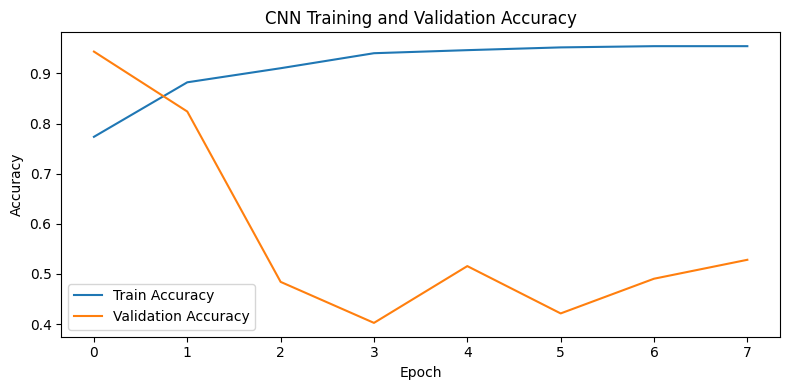

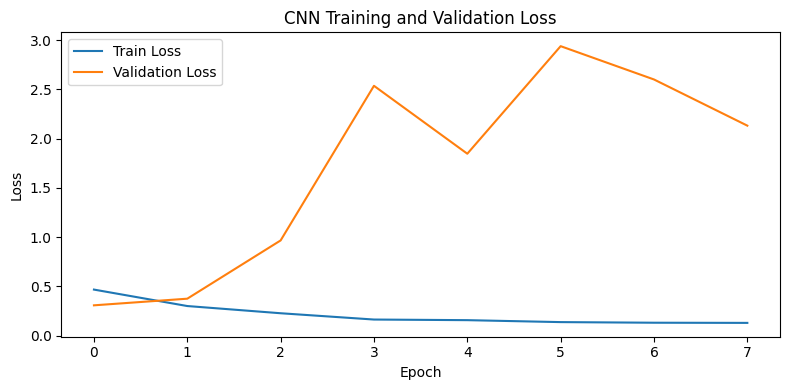

              precision    recall  f1-score   support

    non_wasp       0.87      1.00      0.93        60
        wasp       1.00      0.91      0.95        99

    accuracy                           0.94       159
   macro avg       0.93      0.95      0.94       159
weighted avg       0.95      0.94      0.94       159



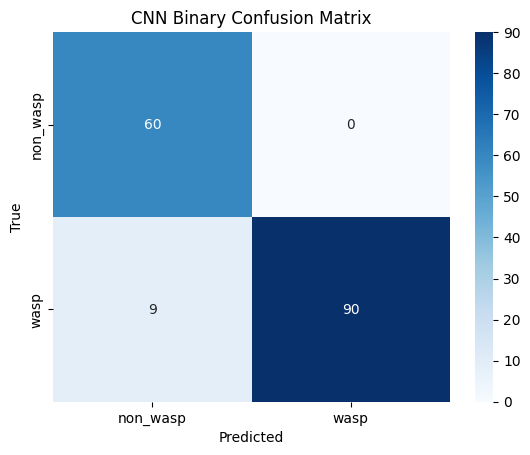

{'Model': 'CNN', 'Accuracy': 0.9433962264150944, 'Precision': 0.9347826086956521, 'Recall': 0.9545454545454546, 'Macro F1': 0.9413067552602437, 'Wasp Recall': 0.9090909090909091, 'Wasp Precision': 1.0, 'False Negative': 9, 'False Positive': 0, 'False Positive Rate': 0.0}


In [26]:
'''
CNN Validation 평가
'''

# 클래스별 확률을 예측
cnn_val_pred_probs = cnn_model.predict(X_val_cnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
cnn_val_pred_classes = predict_classes(cnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(cnn_history, 'CNN')

cnn_val_result = evaluate_model(y_val_mel, cnn_val_pred_classes, 'CNN')

## 4-3. MobileNetV2

사전 학습된 MobileNetV2 모델을 활용하여 Mel-Spectrogram을 분류한다

- 입력: 128 x 128 x 3 Mel-Spectrogram
- 출력 클래서: non_wasp / wasp
- ImageNet 사전 학습 가중치를 활용한 Transfer Learning 사용
- MobileNetV2의 기본 특징 추출층은 동결하여 학습
- CNN 모델과 동일한 Train / Val / Test 데이터를 사용

In [27]:
'''
Mel-Spectrogram 기반 MobileNetV2 분류 모델

- ImageNet으로 사전 학습된 MobileNetV2를 특징 추출기로 사용한다.
- 데이터셋이 작기 때문에 기본 MobileNetV2 층은 동결한다.
- 마지막 분류층만 non_wasp / wasp 분류에 맞게 새로 학습한다.
'''

# MobileNetV2 입력 shape
mobilenet_input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 사전 학습된 MobileNetV2 불러오기
mobilenet_base = MobileNetV2(
    input_shape = mobilenet_input_shape,
    include_top = False,
    weights = 'imagenet'
)

# 사전 학습된 특징 추출층 동결
mobilenet_base.trainable = False

# 분류 모델 구성
mobilenet_model = models.Sequential([
    layers.Input(shape = mobilenet_input_shape),

    mobilenet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.5),

    layers.Dense(len(CLASSES), activation = 'softmax')
])

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
'''
MobileNetV2 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# MobileNetV2 모델 저장 경로
MOBILENET_MODEL_PATH = os.path.join(MODEL_DIR, 'mobilenetv2.keras')

# Model Compile
mobilenet_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
mobilenet_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
mobilenet_checkpoint = ModelCheckpoint(
    filepath = MOBILENET_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('MobileNetV2 Model Path: ', MOBILENET_MODEL_PATH)

MobileNetV2 Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras


In [29]:
'''
MobileNetV2 학습
'''

mobilenet_history = mobilenet_model.fit(
    X_train_mobile,
    y_train_mel,
    validation_data = (X_val_mobile, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [mobilenet_early_stopping, mobilenet_checkpoint],
    verbose = 1
)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9214 - loss: 0.1998
Epoch 1: val_loss improved from None to 0.25507, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.9597 - loss: 0.1109 - val_accuracy: 0.8931 - val_loss: 0.2551
Epoch 2/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9857 - loss: 0.0493
Epoch 2: val_loss improved from 0.25507 to 0.14206, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\mobilenetv2.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9896 - loss: 0.0369 - val_accuracy: 0.9371 - val_loss: 0.1421
Epoch 3/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9896 - loss: 0.0345
Epoch 3: val_loss did not improve from 0.14206
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9927 - loss: 0.0247 - val_accuracy: 0.9308 - val_loss: 0.2086
Epoch 4/50
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9958

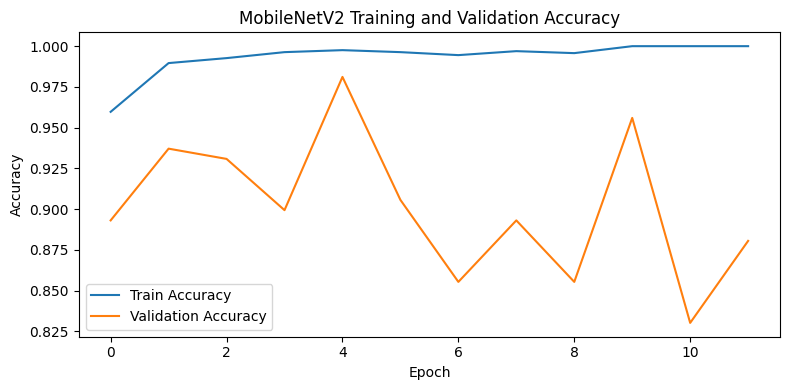

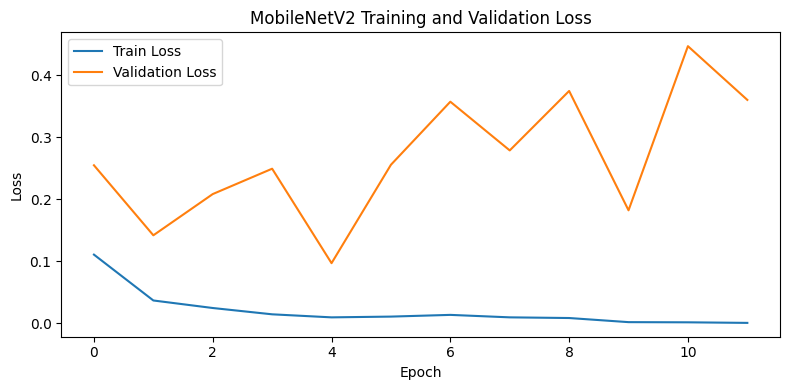

              precision    recall  f1-score   support

    non_wasp       0.95      1.00      0.98        60
        wasp       1.00      0.97      0.98        99

    accuracy                           0.98       159
   macro avg       0.98      0.98      0.98       159
weighted avg       0.98      0.98      0.98       159



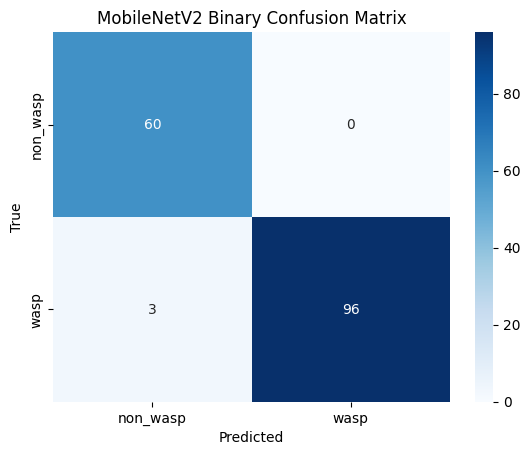

{'Model': 'MobileNetV2', 'Accuracy': 0.9811320754716981, 'Precision': 0.9761904761904762, 'Recall': 0.9848484848484849, 'Macro F1': 0.9801125703564728, 'Wasp Recall': 0.9696969696969697, 'Wasp Precision': 1.0, 'False Negative': 3, 'False Positive': 0, 'False Positive Rate': 0.0}


In [30]:
'''
MobileNetV2 Validation 평가
'''

# 클래스 별 확률 예측
mobilenet_val_pred_probs = mobilenet_model.predict(X_val_mobile, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
mobilenet_val_pred_classes = predict_classes(mobilenet_val_pred_probs, WASP_THRESHOLD)

plot_training_history(mobilenet_history, 'MobileNetV2')

mobilenet_val_result = evaluate_model(y_val_mel, mobilenet_val_pred_classes, 'MobileNetV2')

## 4-4. CRNN

Mel-Spectrogram의 공간적 특징과 시간적 변화를 함께 학습하기 위해 CNN과 RNN을 결합한 CRNN 모델을 구성한다.

- CNN을 통해 주파수 패턴의 특징을 추출
- RNN(GRU)을 통해 시간에 따른 특징 변화를 학습
- 출력 클래스: non_wasp / wasp
- CNN, MobileNetV2와 동일한 Train / Val / Test 데이터 사용

In [31]:
'''
Mel-Spectrogram 기반 CRNN 분류 모델

- CNN으로 Mel-Spectrogram의 주요 특징을 추출한다.
- GRU를 사용하여 시간에 따른 특징 변화를 학습한다.
- non_wasp / wasp 2개 클래스를 분류한다.
'''

# CRNN 입력 shape
crnn_input_shape = X_train_crnn.shape[1:]

# 입력층
crnn_input = layers.Input(shape = crnn_input_shape)

# =========================
# CNN Feature 추출
# =========================

x = layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same')(crnn_input)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same')(x)
x = layers.MaxPooling2D(pool_size = (2, 2))(x)

# =========================
# CNN → RNN 형태 변환
# =========================

# 현재 CNN 출력 shape에서 시간 축을 sequence로 사용하도록 변환
shape = x.shape

x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

x = layers.Dense(128, activation = 'relu')(x)

# =========================
# GRU
# =========================

x = layers.GRU(64)(x)

# =========================
# Classification
# =========================

x = layers.Dense(64, activation = 'relu')(x)
x = layers.Dropout(0.5)(x)

crnn_output = layers.Dense(len(CLASSES), activation = 'softmax')(x)
crnn_model = models.Model(inputs = crnn_input, outputs = crnn_output)

crnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 188, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 188, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 94, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 47, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 47, 128)        │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,626 (1.23 MB)

 Trainable params: 322,626 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
'''
CRNN 모델 컴파일 및 학습 콜백 설정
'''

ensure_directory_exists(MODEL_DIR)

# CRNN 모델 저장 경로
CRNN_MODEL_PATH = os.path.join(MODEL_DIR, 'crnn.keras')

# 모델 컴파일
crnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Validation Loss가 개선되지 않으면 조기 종료
crnn_early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    restore_best_weights = True
)

# Validation Loss가 가장 낮은 모델 저장
crnn_checkpoint = ModelCheckpoint(
    filepath = CRNN_MODEL_PATH,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1
)

print('CRNN Model Path: ', CRNN_MODEL_PATH)

CRNN Model Path:  E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras


In [33]:
'''
CRNN 모델 학습
'''

crnn_history = crnn_model.fit(
    X_train_crnn,
    y_train_mel,
    validation_data = (X_val_crnn, y_val_mel),
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    class_weight = class_weights,
    callbacks = [crnn_early_stopping, crnn_checkpoint],
    verbose = 1
)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6667 - loss: 0.5517
Epoch 1: val_loss improved from None to 0.99021, saving model to E:\AI_First_Team_Project\Buzz\ai_model\models\crnn.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.8150 - loss: 0.3875 - val_accuracy: 0.6478 - val_loss: 0.9902
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9280 - loss: 0.2408
Epoch 2: val_loss did not improve from 0.99021
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.9328 - loss: 0.2136 - val_accuracy: 0.6226 - val_loss: 1.0729
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9610 - loss: 0.1367
Epoch 3: val_loss did not improve from 0.99021
103/103 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.9621 - loss: 0.1232 - val_accuracy: 0.5535 - val_loss: 1.7269
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9531 - loss: 0.1268
Epoch 4: val_loss did not improve from 0.99021
103/103 ━━━━━━━━━━━━━━━━━

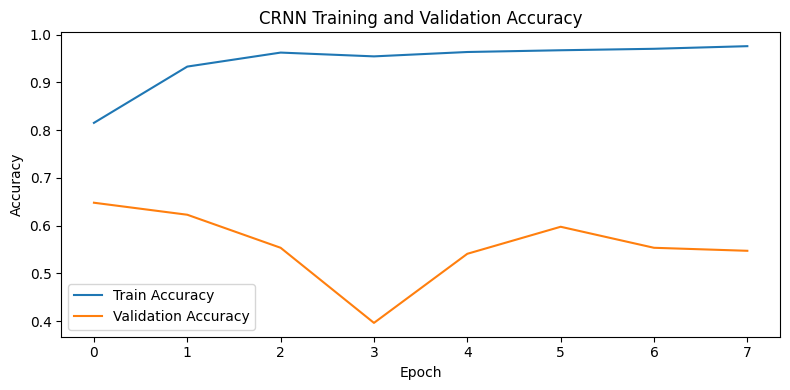

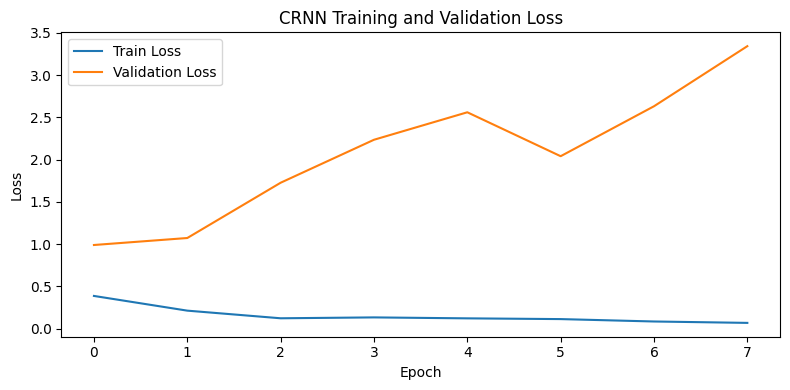

              precision    recall  f1-score   support

    non_wasp       0.52      1.00      0.68        60
        wasp       1.00      0.43      0.61        99

    accuracy                           0.65       159
   macro avg       0.76      0.72      0.64       159
weighted avg       0.82      0.65      0.63       159



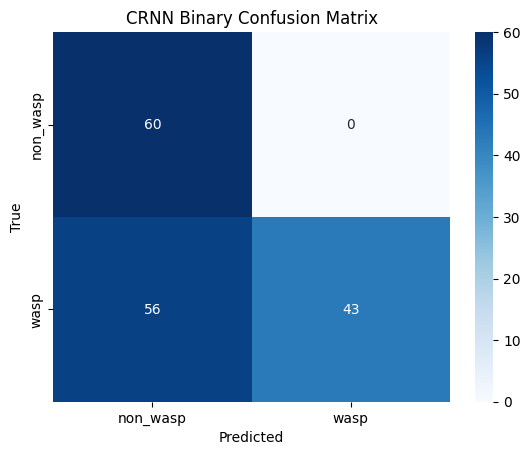

{'Model': 'CRNN', 'Accuracy': 0.6477987421383647, 'Precision': 0.7586206896551724, 'Recall': 0.7171717171717171, 'Macro F1': 0.6437259923175416, 'Wasp Recall': 0.43434343434343436, 'Wasp Precision': 1.0, 'False Negative': 56, 'False Positive': 0, 'False Positive Rate': 0.0}


In [34]:
'''
CRNN Validation 평가
'''

# 클래스 별 확률 예측
crnn_val_pred_probs = crnn_model.predict(X_val_crnn, verbose = 0)

# 말벌 확률이 임계값 이상이면 wasp로 판정
crnn_val_pred_classes = predict_classes(crnn_val_pred_probs, WASP_THRESHOLD)

plot_training_history(crnn_history, 'CRNN')

crnn_val_result = evaluate_model(y_val_mel, crnn_val_pred_classes, 'CRNN')

# 5. Machine Learning

## 5-1. Feature 추출

오디오 파일에서 전통적인 머신러닝 모델이 사용할 수 있도록 고정 길이의 음향 특징을 추출한다.

사용 특징:
- MFCC
- Chroma
- Spectral Centroid
- Spectral Bandwidth
- Spectral Rolloff
- Zero Crossing Rate
- RMS

In [35]:
# ML 특징은 Mel 특징과 동일한 파형으로 이미 생성했습니다.


In [36]:
print('ML features:', X_ml.shape, 'labels:', y_ml.shape)

ML features: (2000, 74) labels: (2000,)


In [37]:
# DL과 정확히 같은 source 분할 사용
X_train_ml, X_val_ml, X_test_ml = [X_ml[i].copy() for i in (train_indices, val_indices, test_indices)]
y_train_ml, y_val_ml, y_test_ml = [y_ml[i] for i in (train_indices, val_indices, test_indices)]
# DL에서 교체한 것과 정확히 같은 위치에 동일 혼합음의 ML 특징을 적용합니다.
if replacement_positions:
    X_train_ml[replacement_positions] = np.asarray(replacement_ml, dtype=np.float32)
np.testing.assert_array_equal(X_val_ml, X_ml[val_indices])
np.testing.assert_array_equal(X_test_ml, X_ml[test_indices])
assert len(X_train_ml) == len(X_train_mel)
assert np.array_equal(y_train_ml, y_train_mel), 'DL/ML 학습 라벨이 일치해야 합니다.'
ml_sample_weights = compute_sample_weight('balanced', y_train_ml)

## 5-2. Random Forest

- RandomForest
> 여러 개의 Decision Tree를 구성하고, 각 Tree의 예측 결과를 종합하여 최종 클래스를 결정하는 앙상블 기반 머신러닝 모델.

In [38]:
'''
RF 분류 모델 학습
'''

rf_model = RandomForestClassifier(n_estimators = 200, random_state = SEED, n_jobs = -1, class_weight = 'balanced')

rf_model.fit(X_train_ml, y_train_ml)

print('RandomForest 학습 완료')

RandomForest 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.56      1.00      0.72        60
        wasp       1.00      0.53      0.69        99

    accuracy                           0.70       159
   macro avg       0.78      0.76      0.70       159
weighted avg       0.83      0.70      0.70       159



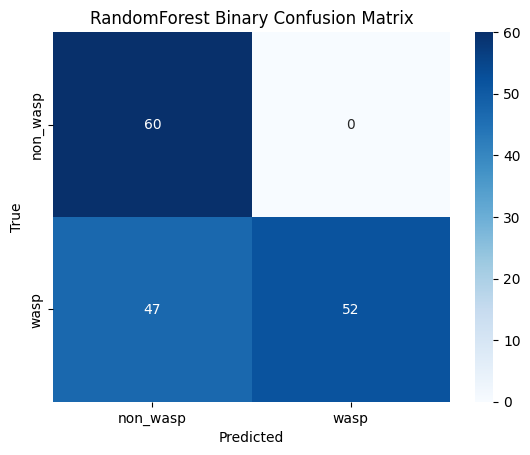

{'Model': 'RandomForest', 'Accuracy': 0.7044025157232704, 'Precision': 0.780373831775701, 'Recall': 0.7626262626262627, 'Macro F1': 0.7036522980529007, 'Wasp Recall': 0.5252525252525253, 'Wasp Precision': 1.0, 'False Negative': 47, 'False Positive': 0, 'False Positive Rate': 0.0}


In [39]:
'''
RandomForest Validation 평가
'''

# 예측
rf_val_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_val_ml), WASP_THRESHOLD)

rf_val_result = evaluate_model(y_val_ml, rf_val_pred_classes, 'RandomForest')

## 5-3. LightGBM

- Light GBM
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러개의 Decision Tree를 순차적으로 학습하면서 이전 Tree의 오차를 보완하는 방식으로 성능을 개선

In [40]:
'''
LightGBM 분류 모델 학습
'''

lgbm_model = LGBMClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    random_state = SEED,
    verbosity = -1,
    objective = 'binary'
)

lgbm_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('LightGBM 학습 완료')

LightGBM 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.53      1.00      0.69        60
        wasp       1.00      0.45      0.62        99

    accuracy                           0.66       159
   macro avg       0.76      0.73      0.66       159
weighted avg       0.82      0.66      0.65       159



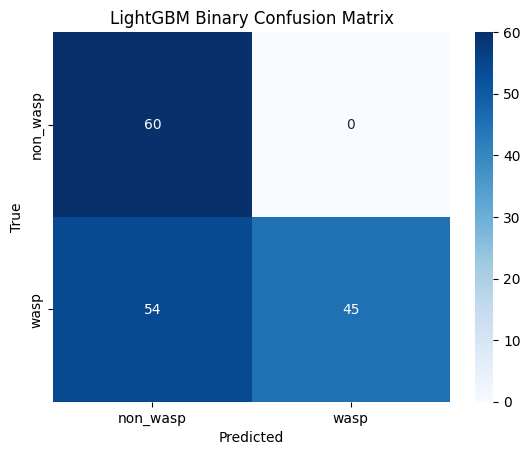

{'Model': 'LightGBM', 'Accuracy': 0.660377358490566, 'Precision': 0.763157894736842, 'Recall': 0.7272727272727273, 'Macro F1': 0.6573275862068966, 'Wasp Recall': 0.45454545454545453, 'Wasp Precision': 1.0, 'False Negative': 54, 'False Positive': 0, 'False Positive Rate': 0.0}


In [41]:
'''
LightGBM Validation 평가
'''

lgbm_val_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_val_ml), WASP_THRESHOLD)

lgbm_val_result = evaluate_model(y_val_ml, lgbm_val_pred_classes, 'LightGBM')

## 5-4. XGBoost

- XGBoost
> Gradient Boosting 기반의 머신러닝 모델.  
> 여러 개의 Decision Tree를 순차적으로 학습하면서 이전 모델의 오차를 보완하는 방식으로 성능을 개선

In [42]:
'''
XGBoost 분류 모델 학습
'''

xgb_model = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 6,
    random_state = SEED,
    objective = 'binary:logistic',
    eval_metric = 'logloss'
)

xgb_model.fit(X_train_ml, y_train_ml, sample_weight=ml_sample_weights)

print('XGBoost 학습 완료')

XGBoost 학습 완료


              precision    recall  f1-score   support

    non_wasp       0.53      1.00      0.69        60
        wasp       1.00      0.45      0.62        99

    accuracy                           0.66       159
   macro avg       0.76      0.73      0.66       159
weighted avg       0.82      0.66      0.65       159



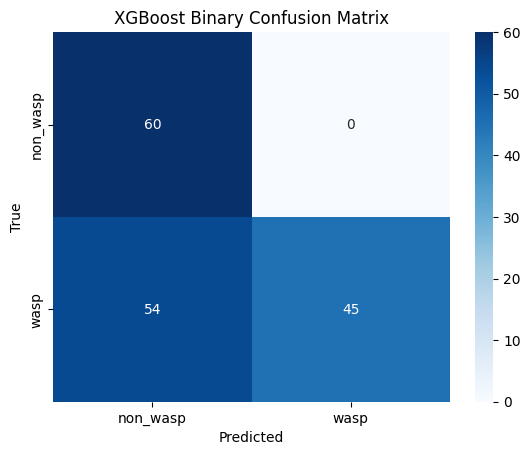

{'Model': 'XGBoost', 'Accuracy': 0.660377358490566, 'Precision': 0.763157894736842, 'Recall': 0.7272727272727273, 'Macro F1': 0.6573275862068966, 'Wasp Recall': 0.45454545454545453, 'Wasp Precision': 1.0, 'False Negative': 54, 'False Positive': 0, 'False Positive Rate': 0.0}


In [43]:
'''
XGBoost Validation 평가
'''

xgb_val_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_val_ml), WASP_THRESHOLD)

xgb_val_result = evaluate_model(y_val_ml, xgb_val_pred_classes, 'XGBoost')

## 5-5. Machine Learning 모델 저장

In [44]:
ensure_directory_exists(MODEL_DIR)

RF_MODEL_PATH = os.path.join(MODEL_DIR, 'randomforest.pkl')
LGBM_MODEL_PATH = os.path.join(MODEL_DIR, 'lightgbm.pkl')
XGB_MODEL_PATH = os.path.join(MODEL_DIR, 'xgboost.pkl')

joblib.dump(rf_model, RF_MODEL_PATH)
joblib.dump(lgbm_model, LGBM_MODEL_PATH)
joblib.dump(xgb_model, XGB_MODEL_PATH)

print('===== Machine Learning 모델 저장 완료 =====')
print('RandomForest : ', RF_MODEL_PATH)
print('LightGBM     : ', LGBM_MODEL_PATH)
print('XGBoost      : ', XGB_MODEL_PATH)

===== Machine Learning 모델 저장 완료 =====
RandomForest :  E:\AI_First_Team_Project\Buzz\ai_model\models\randomforest.pkl
LightGBM     :  E:\AI_First_Team_Project\Buzz\ai_model\models\lightgbm.pkl
XGBoost      :  E:\AI_First_Team_Project\Buzz\ai_model\models\xgboost.pkl


# 6. 모델 성능 비교 및 최종 추론 방식 선정

학습한 모델들의 Validation 성능을 동일한 평가 지표로 비교

- Accuracy
- Precision
- Recall
- Macro F1
- Wasp Recall

Validation 결과를 기준으로 Best Single Model을 선정하고, 이후 Ensemble 방식과 비교하여 최종 추론 방식을 결정

In [45]:
'''
Validation 기준 모델 성능 비교
'''

validation_results = pd.DataFrame([
    cnn_val_result,
    mobilenet_val_result,
    crnn_val_result,
    rf_val_result,
    lgbm_val_result,
    xgb_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준으로 정렬
validation_results = validation_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Validation 모델 성능 비교 =====')
display(validation_results)

# Best Single Model 선정
best_model_name = validation_results.loc[0, 'Model']

print('===== Best Single Model =====')
print(best_model_name)

===== Validation 모델 성능 비교 =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,False Positive Rate
0,MobileNetV2,0.981132,0.976190,0.984848,0.980113,0.969697,1.0,3,0,0.0
1,CNN,0.943396,0.934783,0.954545,0.941307,0.909091,1.0,9,0,0.0
2,RandomForest,0.704403,0.780374,0.762626,0.703652,0.525253,1.0,47,0,0.0
3,LightGBM,0.660377,0.763158,0.727273,0.657328,0.454545,1.0,54,0,0.0
4,XGBoost,0.660377,0.763158,0.727273,0.657328,0.454545,1.0,54,0,0.0
5,CRNN,0.647799,0.758621,0.717172,0.643726,0.434343,1.0,56,0,0.0


===== Best Single Model =====
MobileNetV2


              precision    recall  f1-score   support

    non_wasp       0.63      1.00      0.77        60
        wasp       1.00      0.65      0.79        99

    accuracy                           0.78       159
   macro avg       0.82      0.82      0.78       159
weighted avg       0.86      0.78      0.78       159



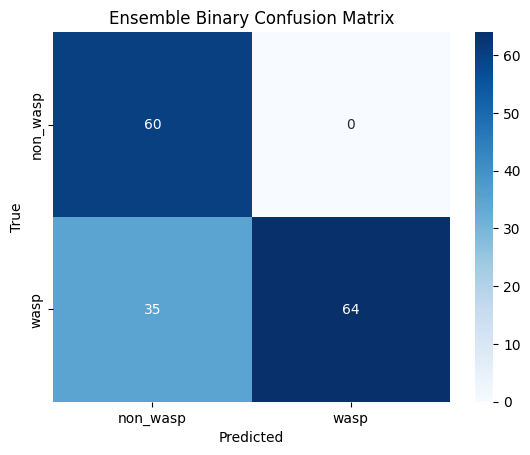

{'Model': 'Ensemble', 'Accuracy': 0.779874213836478, 'Precision': 0.8157894736842105, 'Recall': 0.8232323232323233, 'Macro F1': 0.7797348110033644, 'Wasp Recall': 0.6464646464646465, 'Wasp Precision': 1.0, 'False Negative': 35, 'False Positive': 0, 'False Positive Rate': 0.0}


In [46]:
'''
Soft Voting Ensemble Validation 평가

6개 모델의 클래스별 예측 확률을 평균하여 최종 클래스를 결정
'''

# Machine Learning 모델의 Validation 예측 확률
rf_val_pred_probs = ordered_ml_probabilities(rf_model, X_val_ml)
lgbm_val_pred_probs = ordered_ml_probabilities(lgbm_model, X_val_ml)
xgb_val_pred_probs = ordered_ml_probabilities(xgb_model, X_val_ml)

# Deep Learning + Machine Learning 6개 모델의 확률 평균
ensemble_val_pred_probs = np.mean([
    cnn_val_pred_probs,
    mobilenet_val_pred_probs,
    crnn_val_pred_probs,
    rf_val_pred_probs,
    lgbm_val_pred_probs,
    xgb_val_pred_probs
], axis = 0)

# 평균 말벌 확률에 공통 임계값 적용
ensemble_val_pred_classes = predict_classes(ensemble_val_pred_probs, WASP_THRESHOLD)

# Ensemble Validation 성능 평가
ensemble_val_result = evaluate_model(y_val_mel, ensemble_val_pred_classes, 'Ensemble')

In [47]:
'''
Best Single Model vs Ensemble 비교

Validation 성능을 기준으로 최종 추론 방식 결정
'''

# Best Single Model 결과
best_single_result = validation_results.iloc[0].to_dict()

# 비교용 DataFrame
final_method_results = pd.DataFrame([
    best_single_result,
    ensemble_val_result
])

# Wasp Recall 우선, Macro F1 보조 기준
final_method_results = final_method_results.sort_values(
    by = ['Wasp Recall', 'Macro F1'],
    ascending = [False, False]
).reset_index(drop = True)

print('===== Best Single Model vs Ensemble =====')
display(final_method_results)

# 최종 추론 방식 결정
final_method_name = final_method_results.loc[0, 'Model']

if final_method_name == 'Ensemble':
    final_inference_type = 'ensemble'
    final_model_name = None
else:
    final_inference_type = 'single'
    final_model_name = final_method_name

print('===== 최종 추론 방식 =====')
if final_inference_type == 'ensemble':
    print('Ensemble')
else:
    print(f'Best Single Model : {final_model_name}')

===== Best Single Model vs Ensemble =====


,Model,Accuracy,Precision,Recall,Macro F1,Wasp Recall,Wasp Precision,False Negative,False Positive,False Positive Rate
0,MobileNetV2,0.981132,0.976190,0.984848,0.980113,0.969697,1.0,3,0,0.0
1,Ensemble,0.779874,0.815789,0.823232,0.779735,0.646465,1.0,35,0,0.0


===== 최종 추론 방식 =====
Best Single Model : MobileNetV2


              precision    recall  f1-score   support

    non_wasp       0.98      0.99      0.99       165
        wasp       0.97      0.92      0.95        38

    accuracy                           0.98       203
   macro avg       0.98      0.96      0.97       203
weighted avg       0.98      0.98      0.98       203



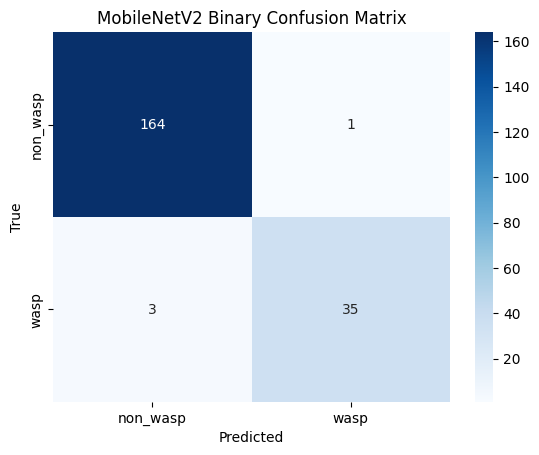

{'Model': 'MobileNetV2', 'Accuracy': 0.9802955665024631, 'Precision': 0.9771290751829673, 'Recall': 0.9574960127591706, 'Macro F1': 0.9669488765874308, 'Wasp Recall': 0.9210526315789473, 'Wasp Precision': 0.9722222222222222, 'False Negative': 3, 'False Positive': 1, 'False Positive Rate': 0.006060606060606061}
===== 최종 Test 결과 =====
최종 추론 방식 : MobileNetV2


In [48]:
'''
최종 추론 방식 Test 평가

Validation에서 결정된 최종 추론 방식을 Test 데이터로 마지막 한 번 더 평가
'''

if final_inference_type == 'ensemble':
    # Deep Learning 모델 Test 예측 확률
    cnn_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
    mobilenet_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
    crnn_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)

    # Machine Learning 모델 Test 예측 확률
    rf_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
    lgbm_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
    xgb_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)

    # Soft Voting
    final_test_pred_probs = np.mean([
        cnn_test_pred_probs,
        mobilenet_test_pred_probs,
        crnn_test_pred_probs,
        rf_test_pred_probs,
        lgbm_test_pred_probs,
        xgb_test_pred_probs
    ], axis = 0)

    final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)

    final_test_name = 'Ensemble'
else:
    if final_model_name == 'CNN':
        final_test_pred_probs = cnn_model.predict(X_test_cnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'MobileNetV2':
        final_test_pred_probs = mobilenet_model.predict(X_test_mobile, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'CRNN':
        final_test_pred_probs = crnn_model.predict(X_test_crnn, verbose = 0)
        final_test_pred_classes = predict_classes(final_test_pred_probs, WASP_THRESHOLD)
    elif final_model_name == 'RandomForest':
        final_test_pred_probs = ordered_ml_probabilities(rf_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(rf_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'LightGBM':
        final_test_pred_probs = ordered_ml_probabilities(lgbm_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(lgbm_model, X_test_ml), WASP_THRESHOLD)
    elif final_model_name == 'XGBoost':
        final_test_pred_probs = ordered_ml_probabilities(xgb_model, X_test_ml)
        final_test_pred_classes = predict_classes(ordered_ml_probabilities(xgb_model, X_test_ml), WASP_THRESHOLD)
    else:
        raise ValueError(f'지원하지 않는 모델입니다: {final_model_name}')

    final_test_name = final_model_name

# 최종 Test 평가
final_test_result = evaluate_model(y_test_mel, final_test_pred_classes, final_test_name)

print('===== 최종 Test 결과 =====')
print(f'최종 추론 방식 : {final_test_name}')

import json
with (MODEL_DIR / 'training_summary.json').open('w', encoding='utf-8') as handle:
    json.dump({
        'classes': CLASSES, 'sampleRate': SR, 'duration': DURATION,
        'waspThreshold': WASP_THRESHOLD, 'seed': SEED,
        'inferenceType': final_inference_type, 'modelName': final_model_name,
        'testMetrics': final_test_result,
        'mixing': mixing_summary,
    }, handle, ensure_ascii=False, indent=2)

# 7. 최종 추론 및 UI 데이터 생성

임의의 WAV 파일 하나를 입력받아 모델 예측 결과와
UI 시각화에 필요한 Waveform, FFT, Spectrogram 데이터를 생성한다.

반환 데이터:
- 예측 클래스
- 예측 확률
- 클래스별 확률
- Waveform
- FFT
- Mel-Spectrogram

In [49]:
from src.visualization import create_audio_visualization_data
# 그래프도 src의 공통 구현을 사용한다.


In [50]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [51]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [52]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [53]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [54]:
# 추론 구현은 src/inference.py로 통일했습니다. 아래 공통 analyze_audio를 사용합니다.


In [55]:
from src.inference import analyze_audio as analyze_binary_audio

trained_models = {
    'CNN': cnn_model, 'MobileNetV2': mobilenet_model, 'CRNN': crnn_model,
    'RandomForest': rf_model, 'LightGBM': lgbm_model, 'XGBoost': xgb_model,
}

def analyze_audio(audio_path, offset=0.0):
    return analyze_binary_audio(
        audio_path, trained_models, final_inference_type, final_model_name,
        threshold=WASP_THRESHOLD, offset=offset,
    )

In [56]:
# 최종 Test 중 한 구간의 실제 파형/이진 확률 확인
# 별도 시연 음원은 경로를 바꾸고 offset(초)을 지정한다.
wasp_test_position = int(np.flatnonzero(y_test_mel == WASP_INDEX)[0])
test_audio_path = str(paths_test_mel[wasp_test_position])
result = analyze_audio(test_audio_path)
print('파일:', test_audio_path)
print('모델:', result['meta']['modelName'])
print('판정:', result['prediction']['label'])
print('확률:', result['prediction']['probabilities'])
print('말벌 임계값:', result['meta']['waspThreshold'])

파일: E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_001.wav
모델: MobileNetV2
판정: non_wasp
확률: {'non_wasp': 0.7378243803977966, 'wasp': 0.26217564940452576}
말벌 임계값: 0.5


In [61]:
# Test로 배정된 모든 파일의 실제 라벨과 최종 모델 예측 결과 확인
test_probabilities = np.asarray(final_test_pred_probs, dtype=np.float64)
test_predictions = predict_classes(test_probabilities, WASP_THRESHOLD)
assert len(paths_test_mel) == len(y_test_mel) == len(test_predictions)

test_file_results = pd.DataFrame({
    'file': [str(path) for path in paths_test_mel],
    'source': [Path(path).parent.name for path in paths_test_mel],
    'actual': [CLASSES[int(label)] for label in y_test_mel],
    'predicted': [CLASSES[int(label)] for label in test_predictions],
    'wasp_probability': test_probabilities[:, WASP_INDEX],
})
test_file_results['correct'] = test_file_results['actual'] == test_file_results['predicted']

print(f'===== 전체 Test 파일 결과: {len(test_file_results)}개 =====')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 120):
    display(test_file_results)

source_test_summary = (test_file_results.groupby(['source', 'actual'], as_index=False)
                       .agg(count=('correct', 'size'),
                            correct=('correct', 'sum'),
                            accuracy=('correct', 'mean'),
                            mean_wasp_probability=('wasp_probability', 'mean')))
source_test_summary['errors'] = source_test_summary['count'] - source_test_summary['correct']
print('===== 원본 폴더별 요약 =====')
display(source_test_summary)
print('전체 정답:', int(test_file_results['correct'].sum()), '/', len(test_file_results))
print('전체 오답:', int((~test_file_results['correct']).sum()))

===== 전체 Test 파일 결과: 203개 =====


,file,source,actual,predicted,wasp_probability,correct
0,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_001.wav,bee2,non_wasp,non_wasp,2.621709e-01,True
1,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_002.wav,bee2,non_wasp,non_wasp,5.022073e-02,True
2,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_003.wav,bee2,non_wasp,non_wasp,6.735989e-03,True
3,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_004.wav,bee2,non_wasp,non_wasp,4.337614e-01,True
4,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee2\bee2_005.wav,bee2,non_wasp,wasp,9.678667e-01,False
5,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee4(env)\bee4_001.wav,bee4(env),non_wasp,non_wasp,1.230330e-04,True
6,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee4(env)\bee4_002.wav,bee4(env),non_wasp,non_wasp,1.214808e-05,True
7,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee4(env)\bee4_003.wav,bee4(env),non_wasp,non_wasp,4.969858e-06,True
8,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee4(env)\bee4_004.wav,bee4(env),non_wasp,non_wasp,9.361664e-05,True
9,E:\AI_First_Team_Project\Buzz\ai_model\audio\non_wasp\bee4(env)\bee4_005.wav,bee4(env),non_wasp,non_wasp,5.240542e-06,True


===== 원본 폴더별 요약 =====


,source,actual,count,correct,accuracy,mean_wasp_probability,errors
0,15-12-22_B_with_sound,wasp,38,35,0.921053,0.917610,3
1,bee2,non_wasp,5,4,0.800000,0.344151,1
2,bee4(env),non_wasp,100,100,1.000000,0.000796,0
3,bee_part6,non_wasp,60,60,1.000000,0.000787,0


전체 정답: 199 / 203
전체 오답: 4
